# Feature Engineering, Scaling & Model Evaluation
### Hack-o-Week | ArpitaBuilds

**Covers:**
- Feature engineering, scaling, handling missing data
- Train/test split, cross-validation
- Confusion matrix, precision/recall/F1, ROC-AUC

**About the dataset:** we're using scikit-learn's built-in **Breast Cancer Wisconsin** dataset — a real
medical dataset, binary classification (malignant / benign), 30 numeric features, 569 patients. It's
structurally almost identical to your stroke project (real patient measurements → predict a 0/1 medical
outcome), and it loads directly from sklearn with zero downloading, so every cell here just runs.




In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report,
                              precision_score, recall_score, f1_score, roc_curve, roc_auc_score)

np.random.seed(42)
plt.rcParams['figure.figsize'] = (6, 5)
PINK, BLUE, GRAY = '#ff2d78', '#2d9dff', '#888888'
print("Setup done ✅")

Setup done ✅


---
## 1. Load Dataset

In [2]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target   # 0 = malignant, 1 = benign

print("Shape:", df.shape)
print("\nClass balance:\n", df['target'].value_counts())
df.head()

Shape: (569, 31)

Class balance:
 target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


---
## 2. Handling Missing Data

Real datasets are almost never clean. This dataset happens to have zero missing values, so we'll
**artificially punch some holes in it** — this is exactly what your actual stroke dataset will look
like (it has real missing values in `bmi`, for example).

Two common strategies:
- **Drop rows/columns** with missing data — simple, but wastes data
- **Impute** (fill in) missing values — mean/median for numeric columns, most-frequent for categorical

In [3]:
# Simulate ~8% missing values scattered across two columns
df_missing = df.copy()
cols_to_corrupt = ['mean radius', 'mean texture']
for col in cols_to_corrupt:
    missing_idx = df_missing.sample(frac=0.08, random_state=1).index
    df_missing.loc[missing_idx, col] = np.nan

print("Missing values per column:\n", df_missing.isnull().sum()[df_missing.isnull().sum() > 0])

# Impute with median (safer than mean when outliers exist)
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(df_missing.drop(columns=['target']))
df_imputed = pd.DataFrame(X_imputed, columns=df.columns[:-1])
df_imputed['target'] = df['target'].values

print("\nMissing values after imputation:", df_imputed.isnull().sum().sum())
print("Median used for 'mean radius':", imputer.statistics_[0].round(3))

Missing values per column:
 mean radius     46
mean texture    46
dtype: int64

Missing values after imputation: 0
Median used for 'mean radius': 13.28


**Key takeaway:** `SimpleImputer(strategy='median')` fills every missing cell in a column with that
column's median — fast, and robust to outliers. For your stroke dataset's missing `bmi` values, this
exact approach applies directly.

---
## 3. Feature Engineering

Feature engineering = creating new, more informative columns from existing ones. A model can only
learn from what's in front of it — sometimes a *ratio* or *combination* of features carries more
signal than the raw numbers alone.

In [4]:
# Example: a ratio feature often carries more signal than either raw feature alone
df_imputed['area_to_perimeter_ratio'] = df_imputed['mean area'] / df_imputed['mean perimeter']

# Example: binning a continuous feature into categories (sometimes helps simpler models)
df_imputed['radius_category'] = pd.cut(df_imputed['mean radius'], bins=[0, 12, 17, 30],
                                        labels=['small', 'medium', 'large'])

print(df_imputed[['mean area', 'mean perimeter', 'area_to_perimeter_ratio', 'mean radius', 'radius_category']].head())
print("\nradius_category distribution:\n", df_imputed['radius_category'].value_counts())

   mean area  mean perimeter  area_to_perimeter_ratio  mean radius  \
0     1001.0          122.80                 8.151466        17.99   
1     1326.0          132.90                 9.977427        20.57   
2     1203.0          130.00                 9.253846        19.69   
3      386.1           77.58                 4.976798        11.42   
4     1297.0          135.10                 9.600296        20.29   

  radius_category  
0           large  
1           large  
2           large  
3           small  
4           large  

radius_category distribution:
 radius_category
medium    302
small     159
large     108
Name: count, dtype: int64


**Connects to your project:** for stroke data, this is exactly where you'd engineer something like
`bmi_category` (underweight/normal/overweight/obese) from raw BMI, or a combined `risk_score` from
age + hypertension + heart disease flags — raw columns become more model-friendly features.

---
## 4. Feature Scaling

Many models (Logistic Regression, KNN, anything gradient-descent-based) are sensitive to the *scale*
of features. If one column ranges 0–1 and another ranges 0–1000, the larger one can dominate purely
because of its units, not because it's more important.

`StandardScaler` transforms each feature to have **mean 0, standard deviation 1**.
(Tree-based models like XGBoost don't need this — they split on thresholds, not distances — but it's
essential for Logistic Regression, KNN, and neural nets.)

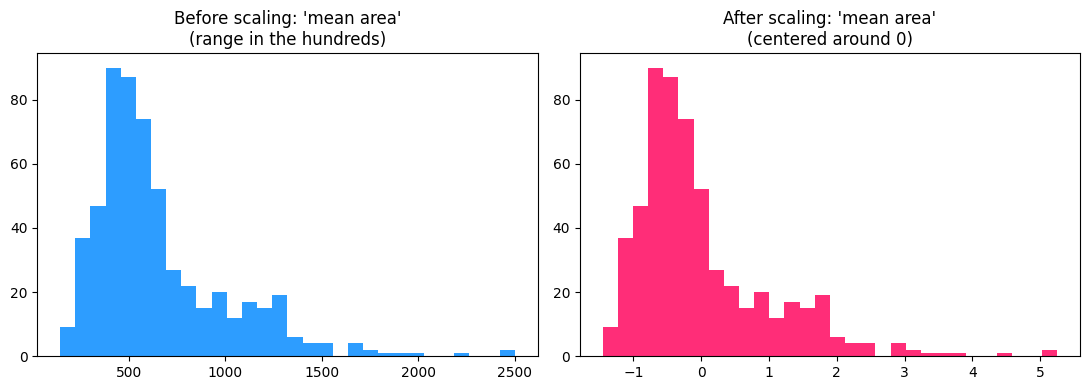

Before -> mean: 654.9  std: 351.9
After  -> mean: -0.0  std: 1.0


In [5]:
feature_cols = [c for c in df_imputed.columns if c not in ['target', 'radius_category']]
X_raw = df_imputed[feature_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(X_raw['mean area'], bins=30, color=BLUE)
axes[0].set_title("Before scaling: 'mean area'\n(range in the hundreds)")
axes[1].hist(X_scaled_df['mean area'], bins=30, color=PINK)
axes[1].set_title("After scaling: 'mean area'\n(centered around 0)")
plt.tight_layout()
plt.show()

print("Before -> mean:", X_raw['mean area'].mean().round(1), " std:", X_raw['mean area'].std().round(1))
print("After  -> mean:", X_scaled_df['mean area'].mean().round(1), " std:", X_scaled_df['mean area'].std().round(1))

---
## 5. Train/Test Split

We never evaluate a model on the same data it trained on — that's like grading a student on the exact
questions they memorized answers to. Splitting keeps a portion of data completely unseen, to check if
the model actually **generalizes**.

In [6]:
y = df_imputed['target']

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])
print("Train class balance:\n", y_train.value_counts(normalize=True).round(3))
print("Test class balance:\n", y_test.value_counts(normalize=True).round(3))

Train size: 455  Test size: 114
Train class balance:
 target
1    0.626
0    0.374
Name: proportion, dtype: float64
Test class balance:
 target
1    0.632
0    0.368
Name: proportion, dtype: float64


**Note the `stratify=y`:** this keeps the same class ratio (malignant vs benign) in both train and
test sets — critical for medical data where classes are rarely 50/50 (your stroke dataset is heavily
imbalanced, so you'll always want `stratify=y` there too).

---
## 6. Cross-Validation

A single train/test split can be lucky or unlucky depending on which rows landed where. **K-Fold
cross-validation** splits the training data into `k` chunks, trains on `k-1` of them and tests on the
last one, then rotates — every row gets used for both training and testing across the `k` rounds. The
final score is the average across all folds, which is a much more reliable estimate of real
performance.

In [7]:
model = LogisticRegression(max_iter=5000)

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')

print("Accuracy per fold:", np.round(cv_scores, 3))
print(f"Mean CV accuracy: {cv_scores.mean():.3f}  (+/- {cv_scores.std():.3f})")

Accuracy per fold: [0.989 0.956 1.    0.978 0.956]
Mean CV accuracy: 0.976  (+/- 0.018)


**Key takeaway:** if the 5 fold scores are close together, the model is stable. Big swings between
folds are a warning sign — the model's performance is sensitive to exactly which rows it happened to
see, which usually means you need more data, better features, or a simpler model.

---
## 7. Train the Final Model

Cross-validation was for *checking* the approach. Now we train on the **full training set** and
evaluate once on the held-out test set.

In [8]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]   # probability of class 1

print("Model trained. First 10 predictions:", y_pred[:10])
print("First 10 true labels:              ", y_test.values[:10])

Model trained. First 10 predictions: [0 1 0 1 0 1 1 0 0 0]
First 10 true labels:               [0 1 0 1 0 1 1 0 0 0]


---
## 8. Confusion Matrix

A confusion matrix breaks predictions into 4 buckets:
- **True Positive (TP):** correctly predicted positive (e.g. correctly caught a stroke case)
- **True Negative (TN):** correctly predicted negative
- **False Positive (FP):** predicted positive, actually negative (a false alarm)
- **False Negative (FN):** predicted negative, actually positive (a **missed** case — the dangerous one in medical settings)

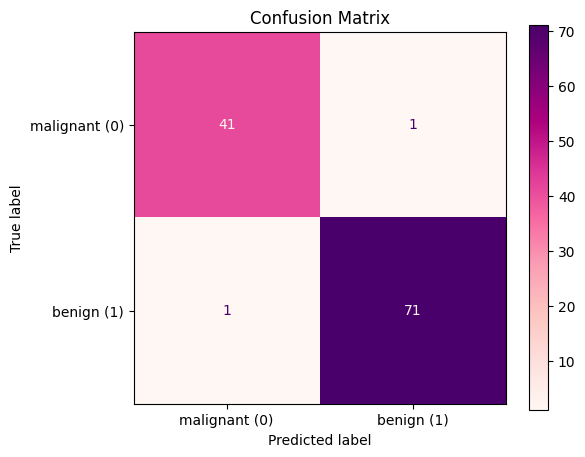

TN=41  FP=1  FN=1  TP=71


In [9]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['malignant (0)', 'benign (1)'])
disp.plot(cmap='RdPu')
plt.title("Confusion Matrix")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")

**Why this matters for your stroke project specifically:** a False Negative here means telling a
patient at real risk of stroke that they're safe — the costliest kind of mistake a medical model can
make. This is exactly why accuracy alone is a misleading metric for imbalanced medical data, and why
we look at precision/recall next.

---
## 9. Precision, Recall, F1-Score

- **Precision** = of everything the model flagged positive, how much was actually positive?
  `TP / (TP + FP)` — high precision means few false alarms.
- **Recall** (a.k.a. sensitivity) = of everything actually positive, how much did the model catch?
  `TP / (TP + FN)` — high recall means few missed cases.
- **F1-score** = harmonic mean of precision and recall — a single number balancing both.

For stroke prediction, **recall usually matters more than precision** — missing a real stroke risk
(false negative) is far more dangerous than flagging a healthy patient for extra caution (false positive).

In [10]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")
print("\nFull classification report:\n")
print(classification_report(y_test, y_pred, target_names=['malignant (0)', 'benign (1)']))

Precision: 0.986
Recall:    0.986
F1-score:  0.986

Full classification report:

               precision    recall  f1-score   support

malignant (0)       0.98      0.98      0.98        42
   benign (1)       0.99      0.99      0.99        72

     accuracy                           0.98       114
    macro avg       0.98      0.98      0.98       114
 weighted avg       0.98      0.98      0.98       114



---
## 10. ROC Curve & AUC

The model doesn't just output 0 or 1 — it outputs a **probability**, and we pick a threshold (default
0.5) to convert it to a class. The ROC curve shows how True Positive Rate vs. False Positive Rate
trade off as you slide that threshold from 0 to 1.

**AUC (Area Under the Curve)** summarizes the whole curve in one number:
- AUC = 1.0 → perfect classifier
- AUC = 0.5 → no better than random guessing
- AUC closer to 1.0 → better at ranking positives above negatives, regardless of threshold choice

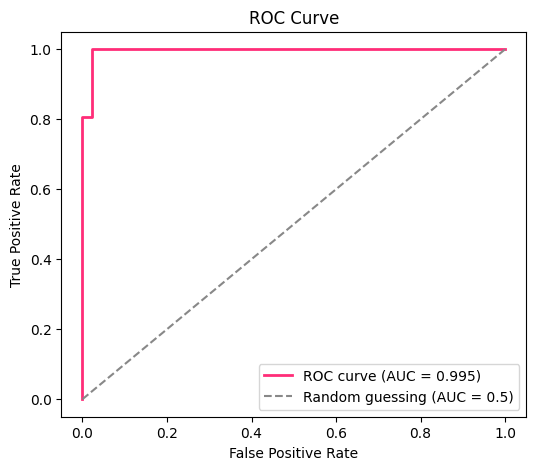

AUC score: 0.995


In [11]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

fig, ax = plt.subplots()
ax.plot(fpr, tpr, color=PINK, linewidth=2, label=f'ROC curve (AUC = {auc_score:.3f})')
ax.plot([0, 1], [0, 1], '--', color=GRAY, label='Random guessing (AUC = 0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()
plt.show()

print(f"AUC score: {auc_score:.3f}")